In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

In [21]:
df = pd.read_csv('../datasets/final-repositories.csv')
df = df.assign(applicable_file_count = None)
df = df.drop(columns=['response_code', 'result_count', 'response_code2', 'result_count2'])
df

,name,applicable_file_count
0,4el1k/Spring-Api-Hibernate-JOOQ,None
1,66xc1/lazy-punch,None
2,ABCLV/ABLV_IngSW,None
3,APSfurizon/fz-backend,None
4,AWS-Cloud-Community-LPU/mailing-service,None
...,...,...
598,zhouzhaodong/springboot,None
599,zhuyb0614/graph-batis,None
600,zigzag191/java-backend-course-2024,None
601,zjxkenshine/codedemo,None


In [22]:
applicable_file_paths = []

# Excluding files generated based on system schemas and database extensions/migration tools
excluded_path_fragments = [
    # Java
    'module-info.java',
    'package-info.java',
    
    # MySQL
    'information_schema/InformationSchema.java',
    'information_schema/tables',
    'mysql/Mysql.java',
    'mysql/tables',
    'performance_schema/PerformanceSchema.java',
    'performance_schema/tables',
    'sys/Sys.java',
    'sys/tables',

    # Flyway
    'FlywaySchemaHistory.java',

    # Liquibase
    'Databasechangelog.java',
    'Databasechangeloglock.java',

    # PostgreSQL
    'information_schema/Domains.java',
    'pg_catalog/PgCatalog.java',
    'pg_catalog/tables',

    # Quartz
    'tables/Qrtz',

    # PGP
    'PgpArmorHeaders.java',

    # Dblink
    'tables/Dblink',

    # hstore
    'tables/Each.java',
    'tables/Skeys.java',
    'tables/Svals.java'
]

# Including files that contain a reference to jOOQ or a potential reference to a generated file (the latter may include false positives)
included_phrases = [
    'org.jooq',
    'Tables',
    'tables'
]

# Excluding generated classes, which contain redundant information that doesn't help with detection
excluded_phrases = [
    'extends TableRecordImpl',
    'extends UpdatableRecordImpl',
    'extends org.jooq.impl.UpdatableRecordImpl',
    'extends CatalogImpl',
    'extends SchemaImpl',
    'extends UDTImpl',
    'extends UDTRecordImpl',
    'extends DAOImpl',
    'extends AbstractRoutine',
    'implements EnumType',
    'implements DeserializableJooqEnum',
    'public class Indexes',
    'public class Keys',
    'public class Routines',
    'public class Sequences',
    'public class Tables',
    'public class Domains',
    'class AbstractSpringDAOImpl',
    'extends AbstractSpringDAOImpl',
    'tables.pojos;',
    'tables.interfaces;',
    'Targeted by JavaCPP'
]

In [23]:
for index, row in df.iterrows():
    project_dir = f"../repositories/{row['name'].replace('/', '_')}"
    all_java_file_paths = glob.glob(project_dir + "/**/src/**/*.java", recursive=True)
    count = 0
    for file_path in all_java_file_paths:
        if all(fragment not in file_path for fragment in excluded_path_fragments) and os.path.isfile(file_path):
            with open(file_path, encoding='latin-1') as file:
                file_contents = file.read()
                if any(phrase in file_contents for phrase in included_phrases) and all(phrase not in file_contents for phrase in excluded_phrases):
                    print(file_path)
                    count += 1
    df.loc[index, 'applicable_file_count'] = count

../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/config/DatabaseConfig.java
../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/config/exception/translator/ExceptionTranslator.java
../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/model/jooq/schema/tables/Account.java
../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/model/jooq/schema/tables/AssociativeListenerMusic.java
../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/model/jooq/schema/tables/Author.java
../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/model/jooq/schema/tables/Listener.java
../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/model/jooq/schema/tables/Manager.java
../repositories/4el1k_Spring-Api-Hibernate-JOOQ/spring-impl/src/main/java/ru/itis/model/jooq/schema/tables/Music.java
../repositories/4el1k

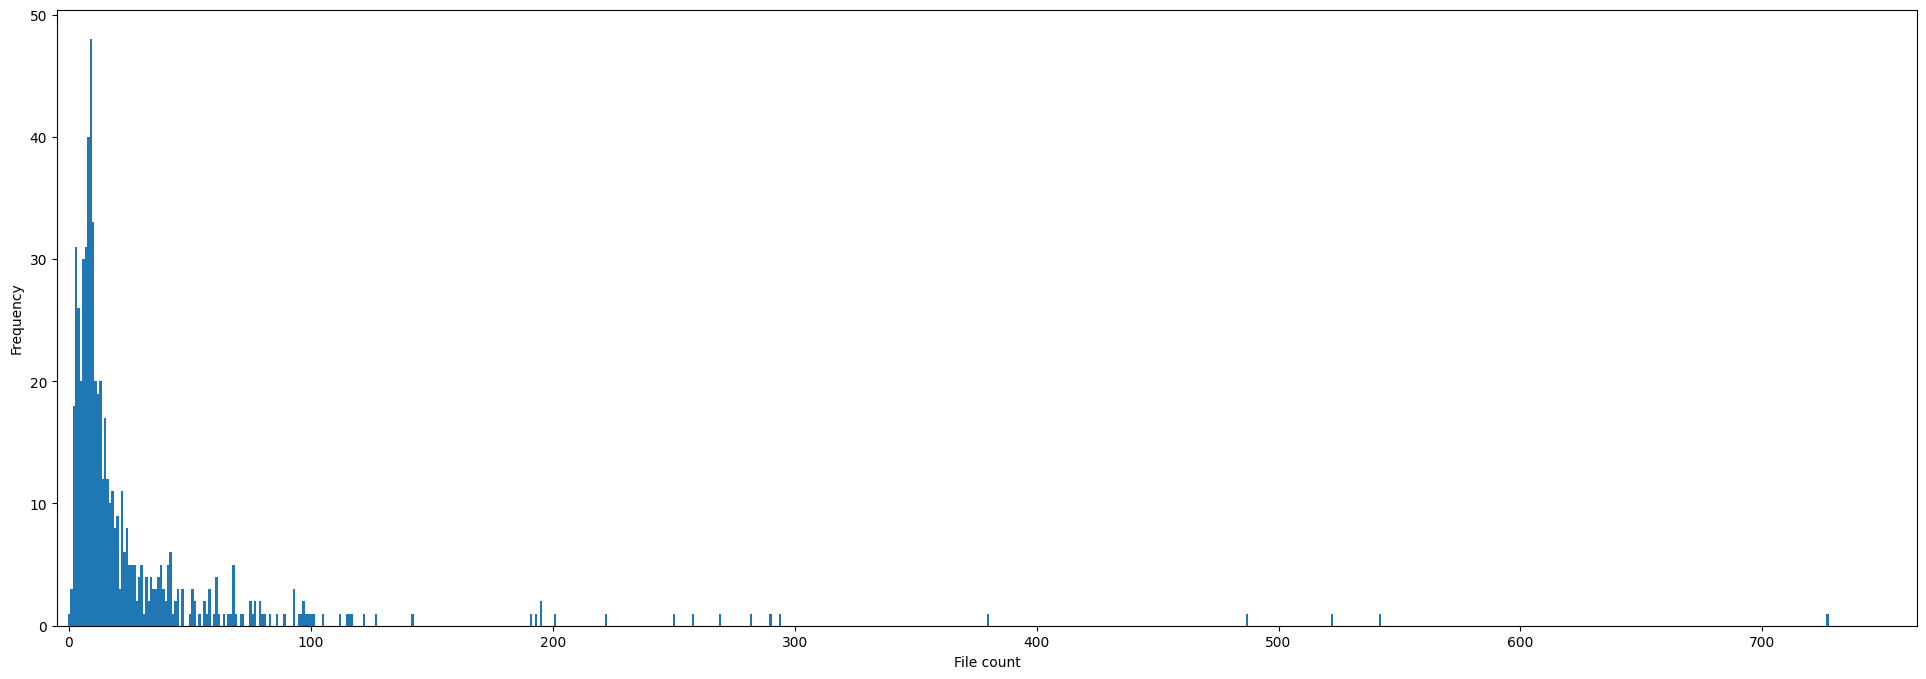

In [15]:
min_val = int(df["applicable_file_count"].min())
max_val = int(df["applicable_file_count"].max())
bins = np.arange(min_val, max_val + 2) - 0.5

df["applicable_file_count"].plot(
    kind="hist", 
    bins=bins,
    figsize=(24, 8)
)
plt.xlabel("File count")
plt.ylabel("Frequency")
plt.xlim(xmin=-5.0)
plt.show()

In [16]:
mean_1 = df["applicable_file_count"].mean()
head = df[df["applicable_file_count"] > mean_1]["applicable_file_count"]
mean_2 = head.mean()

small_max_threshold = round(mean_1)
large_min_threshold = round(mean_2)

print(f"Small: 0 < n <= {small_max_threshold}")
print(f"Medium: {small_max_threshold} < n <= {large_min_threshold}")
print(f"Large: {large_min_threshold} < n")

small = df[df['applicable_file_count'] <= small_max_threshold]
medium = df[(df['applicable_file_count'] > small_max_threshold) & (df['applicable_file_count'] <= large_min_threshold)]
large = df[df['applicable_file_count'] > large_min_threshold]

print(f"Small count: {len(small)}")
print(f"Medium count: {len(medium)}")
print(f"Large count: {len(large)}")

seed = 123456

Small: 0 < n <= 29
Medium: 29 < n <= 91
Large: 91 < n
Small count: 468
Medium count: 98
Large count: 36


In [17]:
small_sample_percentage = 0.1
small_sample = small.sample(frac=small_sample_percentage, random_state=seed)
small_sample

,name,applicable_file_count
441,nuromirzak/tinkoff_academy,11
49,DiSSCo/dissco-core-annotation-processing-service,22
34,BuchnevDmitry/LinkTracker,8
123,Macbeth-Klm/Tinkoff-java-course-2024,9
139,NevinTure/java-course-2024,15
263,chriswininger/ai-document-query-system,10
30,BluBluBlaBla/vidsummize,2
85,Hamednallah/Market-POS,11
282,diocorrea/imagewrapper,4
137,Ne1loff/OnboardingPlatform,20


In [18]:
medium_sample_percentage = 0.1
medium_sample = medium.sample(frac=medium_sample_percentage, random_state=seed)
medium_sample

,name,applicable_file_count
509,sjucker/zkmf2024-server,79
393,liuzheming/merchant-feecal-mvp,36
411,mbto/eatlog,39
439,nortal/GovStack-IM-BB-PubSub-Component,42
577,xdnw/Diplocutus,30
192,UniCodeProjects/AmusementParkDB,80
73,FilippoBolis/MED_Progetto_Ing_Software_23_24,34
318,glockyco/Teralizer,41
229,arnaudroger/SimpleFlatMapper,45
100,KGjertsson/macro-hub,58


In [19]:
large_sample_percentage = 0.1
large_sample = large.sample(frac=large_sample_percentage, random_state=seed)
large_sample

,name,applicable_file_count
251,boogiespook/waltz-test,487
485,rodano/rodano,105
3,APSfurizon/fz-backend,116
337,jOOQ/demo,99
